# Supplementary Notebook for Session S04
## Exploratory Data Analysis and Visualization

This notebook generates every plot referenced in the slides. Each section is labeled with the slide it supports. Run all cells to produce the full set of figures.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from scipy import stats

plt.rcParams.update({
    "figure.dpi": 140,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
})

SEED = 42
rng = np.random.RandomState(SEED)

# ---------- Load Palmer Penguins ----------
try:
    from palmerpenguins import load_penguins
    penguins = load_penguins()
except ImportError:
    import seaborn as sns
    penguins = sns.load_dataset("penguins")

SPECIES_COLORS = {"Adelie": "#ff7f0e", "Chinstrap": "#2ca02c", "Gentoo": "#1f77b4"}
print(f"Penguins loaded: {penguins.shape}")

Penguins loaded: (344, 7)


---
## Slide: Quiz debrief (Q2) Anscombe's Quartet

Four datasets with identical mean of x, mean of y, variance of x, variance of y, Pearson correlation, and regression line, but visually distinct.

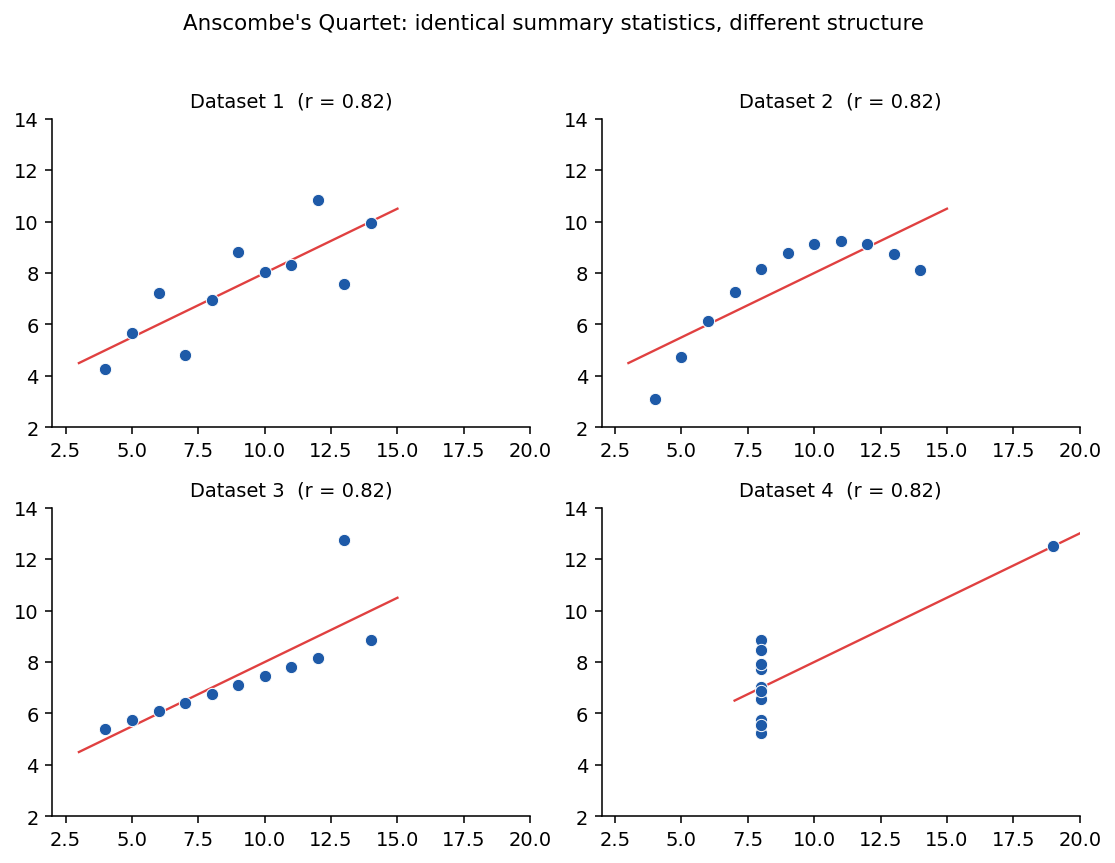

Shared statistics across all four datasets:
  mean(x) = 9.0,  mean(y) = 7.50
  std(x)  = 3.32, std(y)  = 2.03
  r       = 0.816


In [4]:
# Anscombe's quartet (built into many stats packages; we define it directly)
anscombe = {
    1: {"x": [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
        "y": [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68]},
    2: {"x": [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
        "y": [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74]},
    3: {"x": [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
        "y": [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]},
    4: {"x": [8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8],
        "y": [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89]},
}

fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=False, sharey=False)
axes = axes.ravel()

for i, (k, d) in enumerate(anscombe.items()):
    ax = axes[i]
    x, y = np.array(d["x"]), np.array(d["y"])
    ax.scatter(x, y, c="#1e5aa8", s=40, edgecolors="white", linewidths=0.5, zorder=3)
    # Regression line
    slope, intercept = np.polyfit(x, y, 1)
    xline = np.linspace(x.min() - 1, x.max() + 1, 100)
    ax.plot(xline, slope * xline + intercept, color="#e04040", linewidth=1.2, zorder=2)
    r = np.corrcoef(x, y)[0, 1]
    ax.set_title(f"Dataset {k}  (r = {r:.2f})", fontsize=10)
    ax.set_xlim(2, 20)
    ax.set_ylim(2, 14)

fig.suptitle("Anscombe's Quartet: identical summary statistics, different structure",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# Print shared statistics
d1 = anscombe[1]
x1, y1 = np.array(d1["x"]), np.array(d1["y"])
print(f"Shared statistics across all four datasets:")
print(f"  mean(x) = {x1.mean():.1f},  mean(y) = {y1.mean():.2f}")
print(f"  std(x)  = {x1.std(ddof=1):.2f}, std(y)  = {y1.std(ddof=1):.2f}")
print(f"  r       = {np.corrcoef(x1, y1)[0,1]:.3f}")

---
## Slide: Quiz debrief (Q4) Histogram bin-width sensitivity

The same data plotted with 3, ~25 (Freedman-Diaconis), and 50 bins, plus a KDE overlay. The underlying data is a mixture of three Gaussians, so the "true" shape is trimodal.

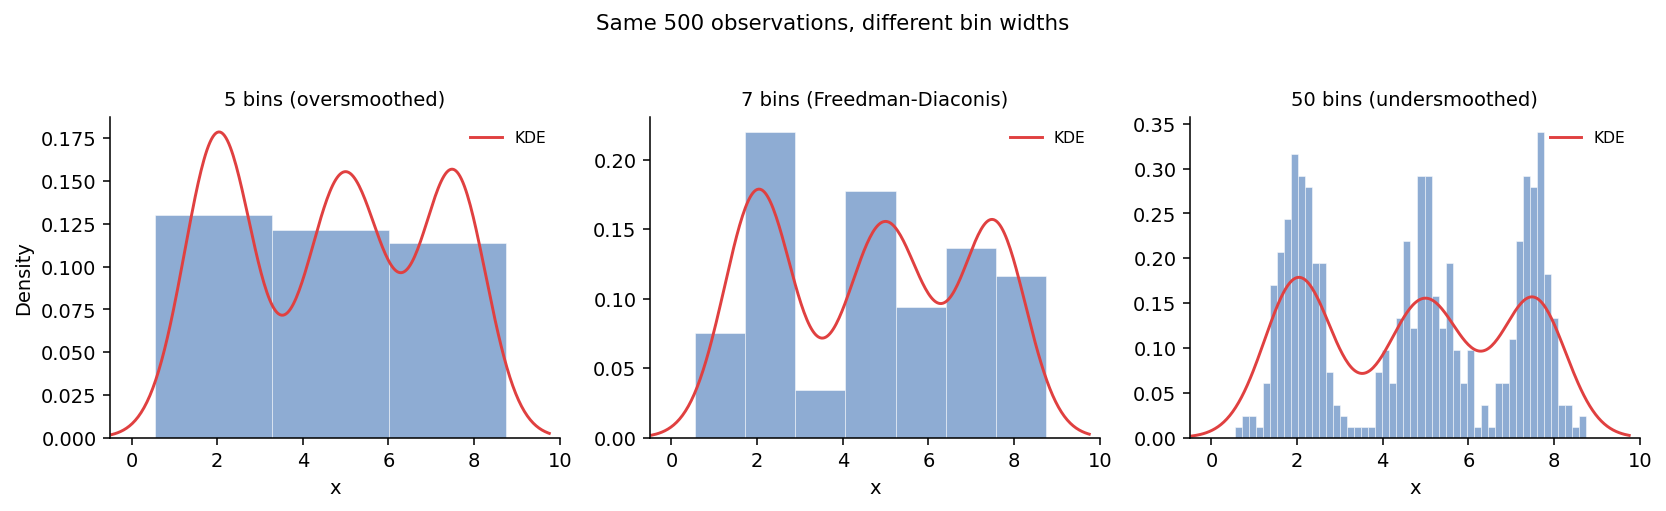

In [ ]:
# Generate trimodal mixture: 500 points from 3 Gaussians
mixture = np.concatenate([
    rng.normal(loc=2, scale=0.5, size=180),
    rng.normal(loc=5, scale=0.6, size=170),
    rng.normal(loc=7.5, scale=0.4, size=150),
])
rng.shuffle(mixture)

# Freedman-Diaconis bin count
iqr = np.percentile(mixture, 75) - np.percentile(mixture, 25)
h_fd = 2 * iqr / len(mixture) ** (1/3)
n_fd = int(np.ceil((mixture.max() - mixture.min()) / h_fd))

bin_counts = [3, n_fd, 50]
titles = ["3 bins (oversmoothed)",
          f"{n_fd} bins (Freedman-Diaconis)",
          "50 bins (undersmoothed)"]

# KDE for overlay
from scipy.stats import gaussian_kde
kde = gaussian_kde(mixture)
x_kde = np.linspace(mixture.min() - 1, mixture.max() + 1, 300)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=False)
for ax, nb, title in zip(axes, bin_counts, titles):
    ax.hist(mixture, bins=nb, density=True, color="#1e5aa8", alpha=0.5,
            edgecolor="white", linewidth=0.5)
    ax.plot(x_kde, kde(x_kde), color="#e04040", linewidth=1.5, label="KDE")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x")
    ax.set_xlim(-0.5, 10)
    if ax == axes[0]:
        ax.set_ylabel("Density")
    ax.legend(frameon=False, fontsize=8)

fig.suptitle("Same 500 observations, different bin widths", fontsize=11, y=1.03)
plt.tight_layout()
plt.show()

---
## Slide: Activity -- Classify these plots (A, B, C, D)

Four plots on Palmer Penguins, one per EDA purpose.

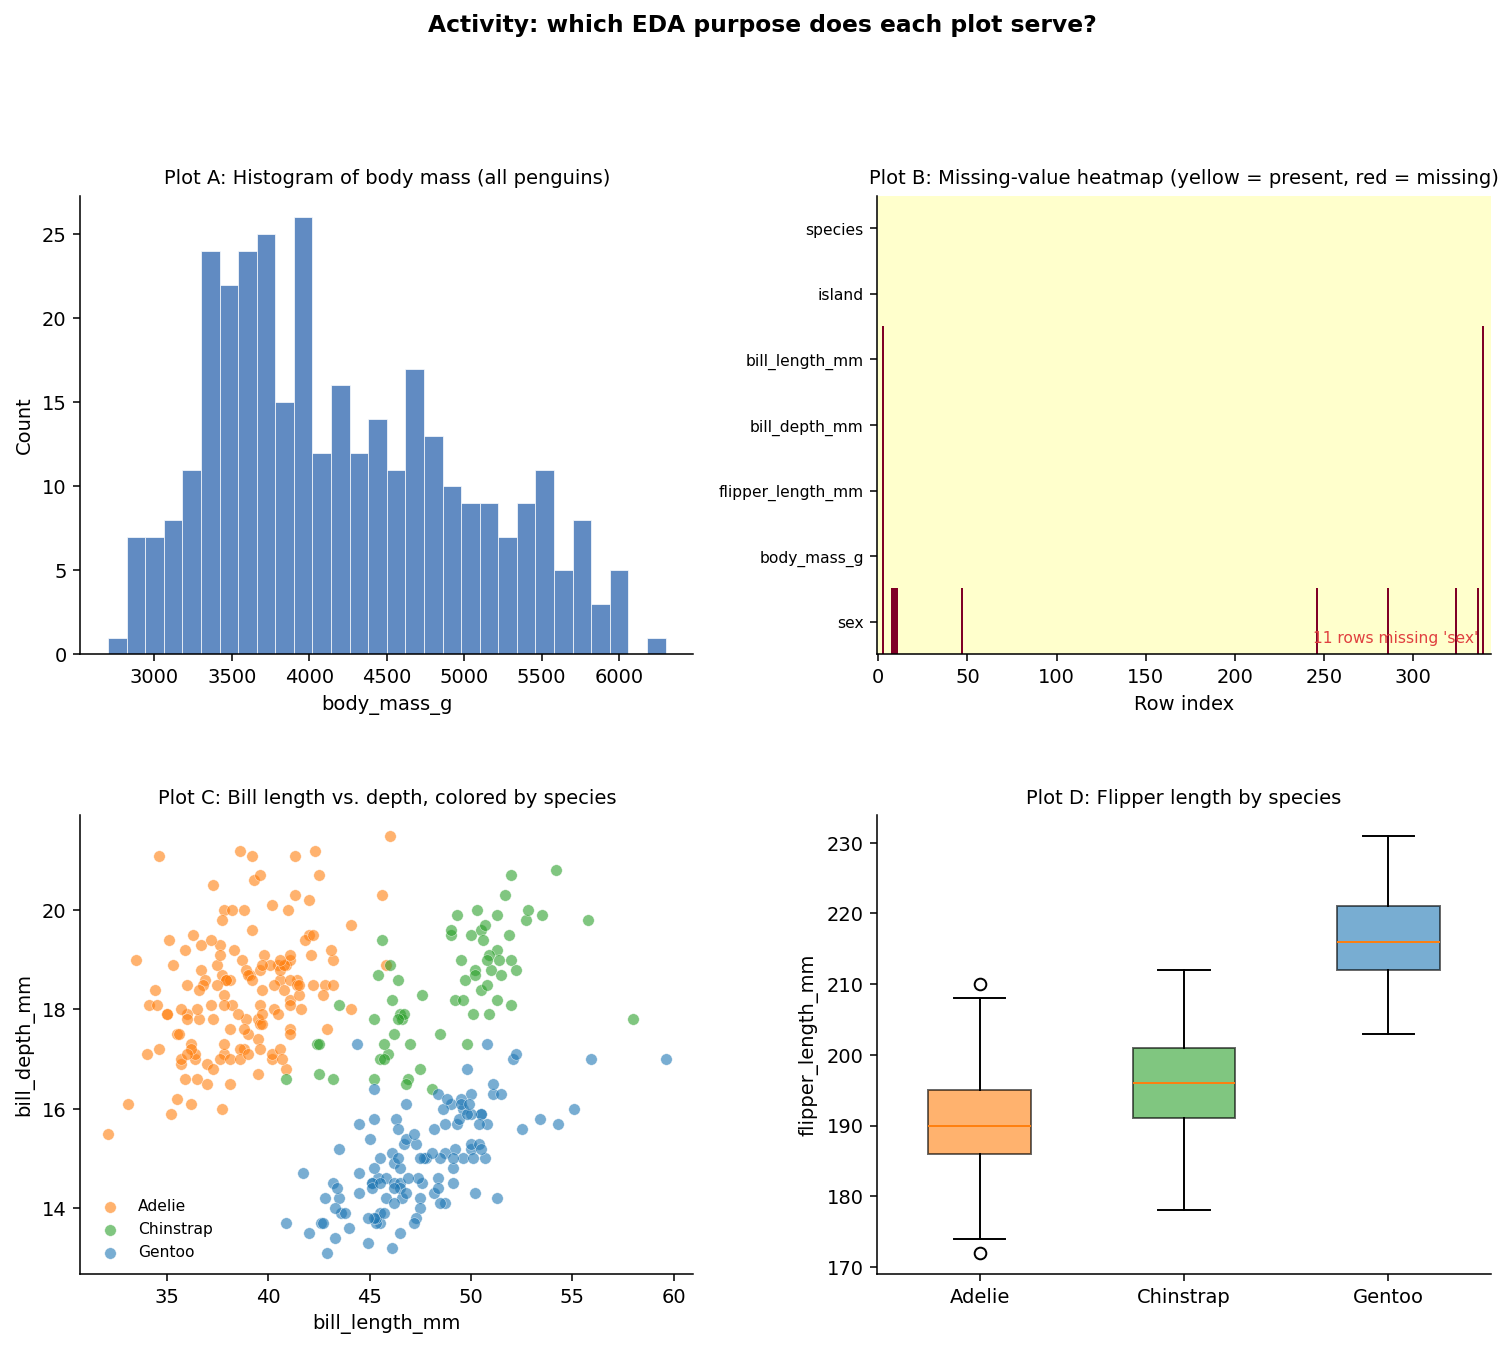

In [4]:
fig = plt.figure(figsize=(13, 10))
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.30)

# ---- Plot A: Histogram of body_mass_g (Describe / Discover) ----
ax_a = fig.add_subplot(gs[0, 0])
ax_a.hist(penguins["body_mass_g"].dropna(), bins=30, color="#1e5aa8",
          alpha=0.7, edgecolor="white", linewidth=0.5)
ax_a.set_xlabel("body_mass_g")
ax_a.set_ylabel("Count")
ax_a.set_title("Plot A: Histogram of body mass (all penguins)", fontsize=10)

# ---- Plot B: Missing-value heatmap (Diagnose) ----
ax_b = fig.add_subplot(gs[0, 1])
missing = penguins.isnull().astype(int)
# Show only columns that have at least one missing value, plus a few others for context
cols_to_show = ["species", "island", "bill_length_mm", "bill_depth_mm",
                "flipper_length_mm", "body_mass_g", "sex"]
missing_subset = missing[cols_to_show]
ax_b.imshow(missing_subset.values.T, aspect="auto", cmap="YlOrRd",
            interpolation="nearest")
ax_b.set_yticks(range(len(cols_to_show)))
ax_b.set_yticklabels(cols_to_show, fontsize=8)
ax_b.set_xlabel("Row index")
ax_b.set_title("Plot B: Missing-value heatmap (yellow = present, red = missing)",
               fontsize=10)
# Add a note about where the missingness is
n_sex_missing = penguins["sex"].isnull().sum()
ax_b.text(0.98, 0.02, f"{n_sex_missing} rows missing 'sex'",
          transform=ax_b.transAxes, fontsize=8, ha="right", va="bottom",
          color="#e04040")

# ---- Plot C: Scatter bill_length vs bill_depth colored by species (Discover) ----
ax_c = fig.add_subplot(gs[1, 0])
for sp in ["Adelie", "Chinstrap", "Gentoo"]:
    sub = penguins[penguins["species"] == sp]
    ax_c.scatter(sub["bill_length_mm"], sub["bill_depth_mm"], label=sp,
                 c=SPECIES_COLORS[sp], alpha=0.6, edgecolors="white",
                 linewidths=0.3, s=35)
ax_c.set_xlabel("bill_length_mm")
ax_c.set_ylabel("bill_depth_mm")
ax_c.set_title("Plot C: Bill length vs. depth, colored by species", fontsize=10)
ax_c.legend(frameon=False, fontsize=8)

# ---- Plot D: Boxplot of flipper_length by species (Decide) ----
ax_d = fig.add_subplot(gs[1, 1])
species_list = ["Adelie", "Chinstrap", "Gentoo"]
data_box = [penguins.loc[penguins["species"] == sp, "flipper_length_mm"].dropna().values
            for sp in species_list]
bp = ax_d.boxplot(data_box, labels=species_list, patch_artist=True, widths=0.5)
for patch, sp in zip(bp["boxes"], species_list):
    patch.set_facecolor(SPECIES_COLORS[sp])
    patch.set_alpha(0.6)
ax_d.set_ylabel("flipper_length_mm")
ax_d.set_title("Plot D: Flipper length by species", fontsize=10)

fig.suptitle("Activity: which EDA purpose does each plot serve?",
             fontsize=12, y=1.01, fontweight="bold")
plt.show()

---
## Slide: Histograms hide; correlations lie -- Datasaurus pair

Two datasets from the Datasaurus Dozen with (nearly) identical summary statistics. 
We generate synthetic approximations: a "dino" shape and a positive-slope line, both matching the same mean, std, and correlation.

Loaded Datasaurus Dozen from GitHub.


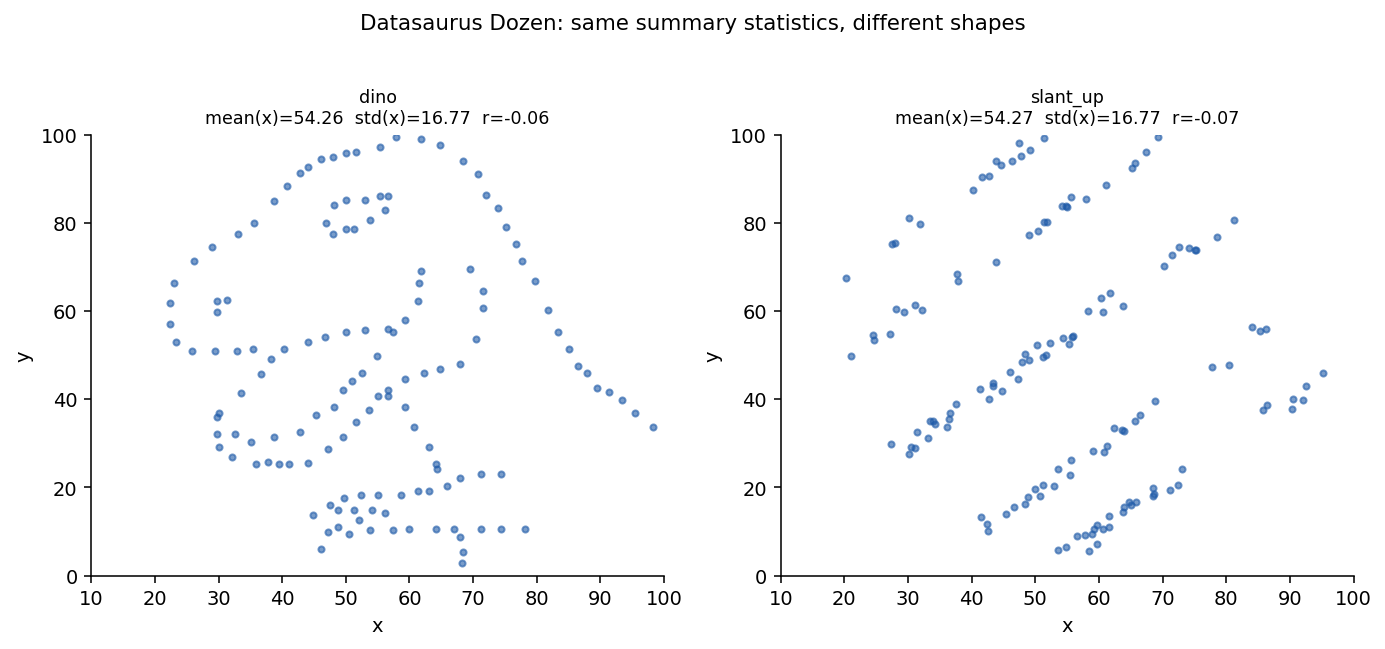

In [5]:
# We use the actual Datasaurus data if available, otherwise synthesize
try:
    # The datasaurus dozen is available in the datasaurus package or as a CSV.
    # Try loading from a common source.
    import importlib
    dino_url = ("https://raw.githubusercontent.com/jumpingrivers/datasauRus/"
                "main/inst/extdata/DatasaurusDozen-Long.tsv")
    ds = pd.read_csv(dino_url, sep="\t")
    dino = ds[ds["dataset"] == "dino"]
    slant = ds[ds["dataset"] == "slant_up"]
    use_real = True
    print("Loaded Datasaurus Dozen from GitHub.")
except Exception:
    use_real = False
    print("Could not load Datasaurus Dozen; using synthetic approximation.")

if use_real:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    for ax, (name, sub) in zip(axes, [("dino", dino), ("slant_up", slant)]):
        ax.scatter(sub["x"], sub["y"], s=10, c="#1e5aa8", alpha=0.6)
        r = np.corrcoef(sub["x"], sub["y"])[0, 1]
        ax.set_title(f"{name}\nmean(x)={sub['x'].mean():.2f}  "
                     f"std(x)={sub['x'].std():.2f}  r={r:.2f}", fontsize=9)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_xlim(10, 100)
        ax.set_ylim(0, 100)
    fig.suptitle("Datasaurus Dozen: same summary statistics, different shapes",
                 fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    # Synthetic fallback: bivariate normal (r=0.75) vs. a ring (r~0)
    n = 200
    xy_normal = rng.multivariate_normal([50, 50], [[100, 75], [75, 100]], size=n)
    theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
    xy_ring = np.column_stack([50 + 20 * np.cos(theta) + rng.normal(0, 1, n),
                               50 + 20 * np.sin(theta) + rng.normal(0, 1, n)])
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    for ax, data, label in zip(axes, [xy_normal, xy_ring],
                                ["Bivariate normal", "Ring"]):
        ax.scatter(data[:, 0], data[:, 1], s=12, c="#1e5aa8", alpha=0.6)
        r = np.corrcoef(data[:, 0], data[:, 1])[0, 1]
        ax.set_title(f"{label} (r = {r:.2f})", fontsize=10)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
    fig.suptitle("Correlation can miss structure entirely",
                 fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

---
## Slide: Activity -- Predict the scatterplot (Rounds 1, 2, 3)

Three datasets with prescribed correlation coefficients, each looking very different from what one might expect.

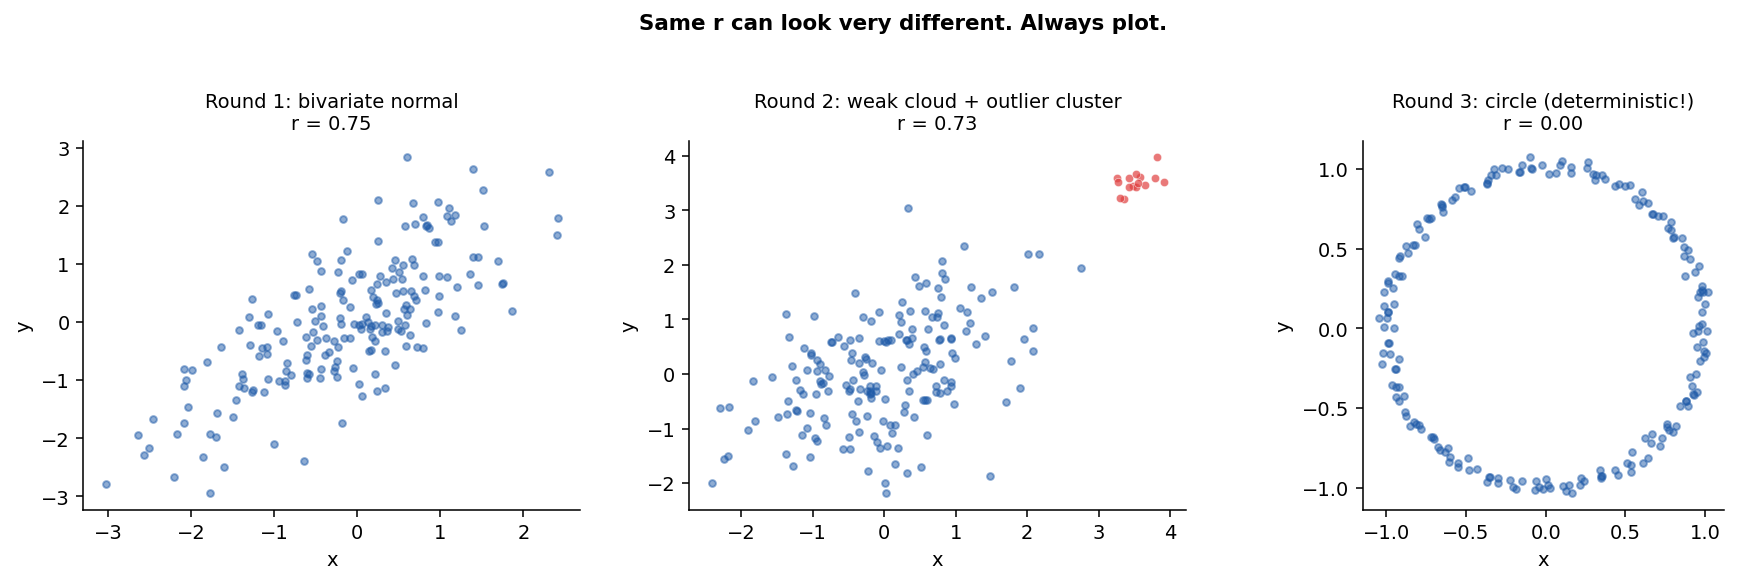

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# ---- Round 1: r = 0.75, bivariate normal ----
n = 200
cov_075 = [[1, 0.75], [0.75, 1]]
xy1 = rng.multivariate_normal([0, 0], cov_075, size=n)
r1 = np.corrcoef(xy1[:, 0], xy1[:, 1])[0, 1]
axes[0].scatter(xy1[:, 0], xy1[:, 1], s=12, c="#1e5aa8", alpha=0.5)
axes[0].set_title(f"Round 1: bivariate normal\nr = {r1:.2f}", fontsize=10)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# ---- Round 2: r ~ 0.75, but from a weak cloud + outlier cluster ----
# Main cloud: 185 points with r ~ 0.50
cov_050 = [[1, 0.50], [0.50, 1]]
xy2_main = rng.multivariate_normal([0, 0], cov_050, size=185)
# Outlier cluster: 15 points in upper right
xy2_outliers = rng.multivariate_normal([3.5, 3.5], [[0.05, 0.03], [0.03, 0.05]], size=15)
xy2 = np.vstack([xy2_main, xy2_outliers])
r2 = np.corrcoef(xy2[:, 0], xy2[:, 1])[0, 1]
axes[1].scatter(xy2_main[:, 0], xy2_main[:, 1], s=12, c="#1e5aa8", alpha=0.5)
axes[1].scatter(xy2_outliers[:, 0], xy2_outliers[:, 1], s=18, c="#e04040",
                alpha=0.7, edgecolors="white", linewidths=0.3)
axes[1].set_title(f"Round 2: weak cloud + outlier cluster\nr = {r2:.2f}",
                  fontsize=10)
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

# ---- Round 3: r = 0.00, perfect circle ----
theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
xy3 = np.column_stack([np.cos(theta) + rng.normal(0, 0.03, n),
                        np.sin(theta) + rng.normal(0, 0.03, n)])
r3 = np.corrcoef(xy3[:, 0], xy3[:, 1])[0, 1]
axes[2].scatter(xy3[:, 0], xy3[:, 1], s=12, c="#1e5aa8", alpha=0.5)
axes[2].set_title(f"Round 3: circle (deterministic!)\nr = {r3:.2f}", fontsize=10)
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].set_aspect("equal")

fig.suptitle("Same r can look very different. Always plot.",
             fontsize=11, y=1.03, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Slide: Simpson's paradox

Bill length vs. bill depth in Palmer Penguins: the overall (aggregated) correlation is weakly negative, but within each species it is positive.

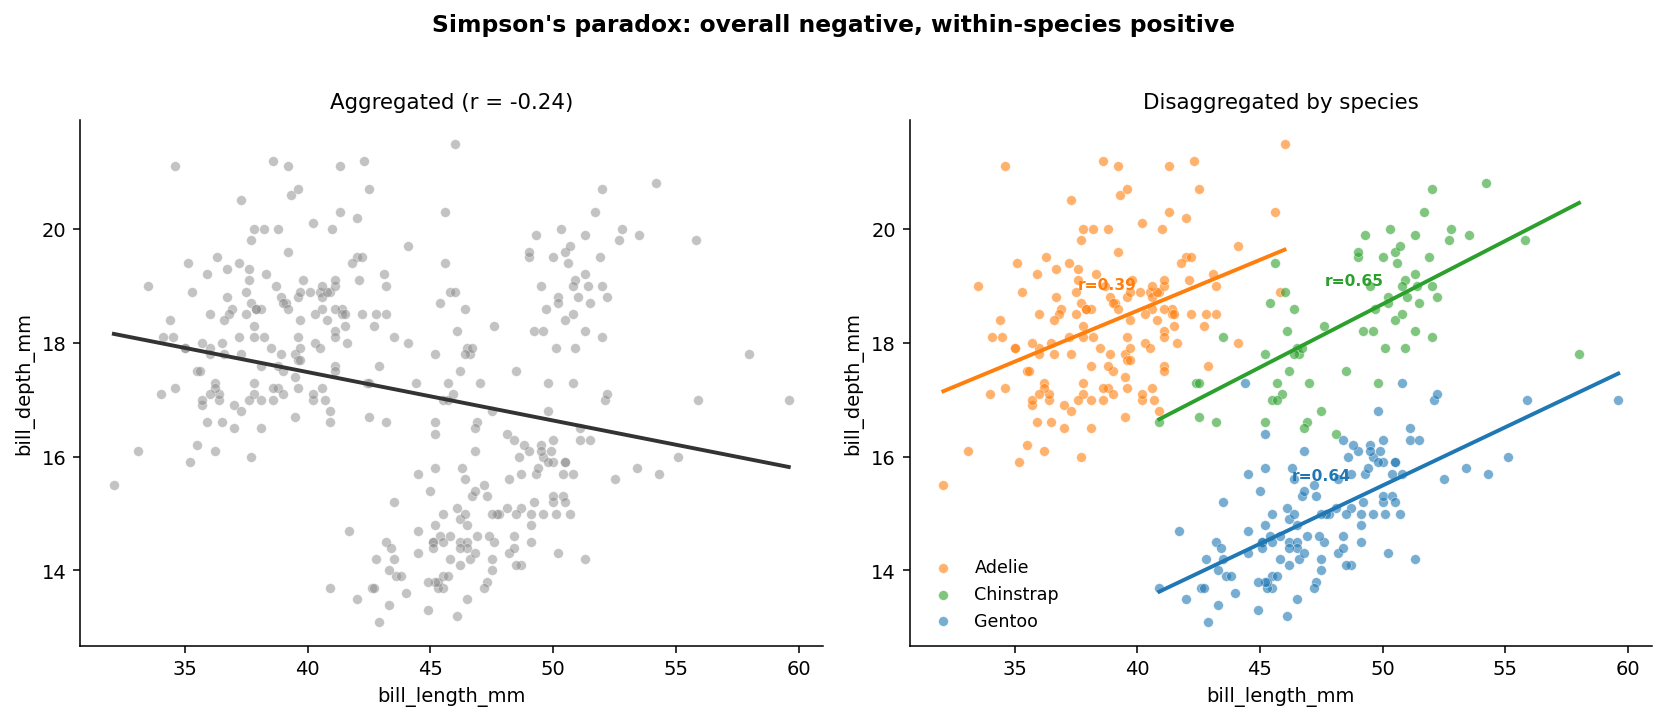

In [7]:
pen_clean = penguins.dropna(subset=["bill_length_mm", "bill_depth_mm", "species"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- Left: aggregated (no color) ----
ax = axes[0]
ax.scatter(pen_clean["bill_length_mm"], pen_clean["bill_depth_mm"],
           c="#888888", alpha=0.5, s=25, edgecolors="white", linewidths=0.3)
# Overall regression line
x_all = pen_clean["bill_length_mm"].values
y_all = pen_clean["bill_depth_mm"].values
slope, intercept = np.polyfit(x_all, y_all, 1)
xline = np.linspace(x_all.min(), x_all.max(), 100)
ax.plot(xline, slope * xline + intercept, color="#333333", linewidth=2)
r_all = np.corrcoef(x_all, y_all)[0, 1]
ax.set_title(f"Aggregated (r = {r_all:.2f})", fontsize=11)
ax.set_xlabel("bill_length_mm")
ax.set_ylabel("bill_depth_mm")

# ---- Right: colored by species with per-species regression ----
ax = axes[1]
for sp in ["Adelie", "Chinstrap", "Gentoo"]:
    sub = pen_clean[pen_clean["species"] == sp]
    ax.scatter(sub["bill_length_mm"], sub["bill_depth_mm"], label=sp,
               c=SPECIES_COLORS[sp], alpha=0.6, s=25,
               edgecolors="white", linewidths=0.3)
    # Per-species regression
    xs = sub["bill_length_mm"].values
    ys = sub["bill_depth_mm"].values
    sl, ic = np.polyfit(xs, ys, 1)
    xr = np.linspace(xs.min(), xs.max(), 50)
    r_sp = np.corrcoef(xs, ys)[0, 1]
    ax.plot(xr, sl * xr + ic, color=SPECIES_COLORS[sp], linewidth=2)
    # Annotate r
    ax.text(xs.mean(), sl * xs.mean() + ic + 0.6, f"r={r_sp:.2f}",
            fontsize=8, color=SPECIES_COLORS[sp], ha="center", fontweight="bold")

ax.set_title("Disaggregated by species", fontsize=11)
ax.set_xlabel("bill_length_mm")
ax.set_ylabel("bill_depth_mm")
ax.legend(frameon=False, fontsize=9)

fig.suptitle("Simpson's paradox: overall negative, within-species positive",
             fontsize=12, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Slide: Activity -- Fix this chart (Charts A, B, C)

Three deliberately bad charts, followed by their improved versions.

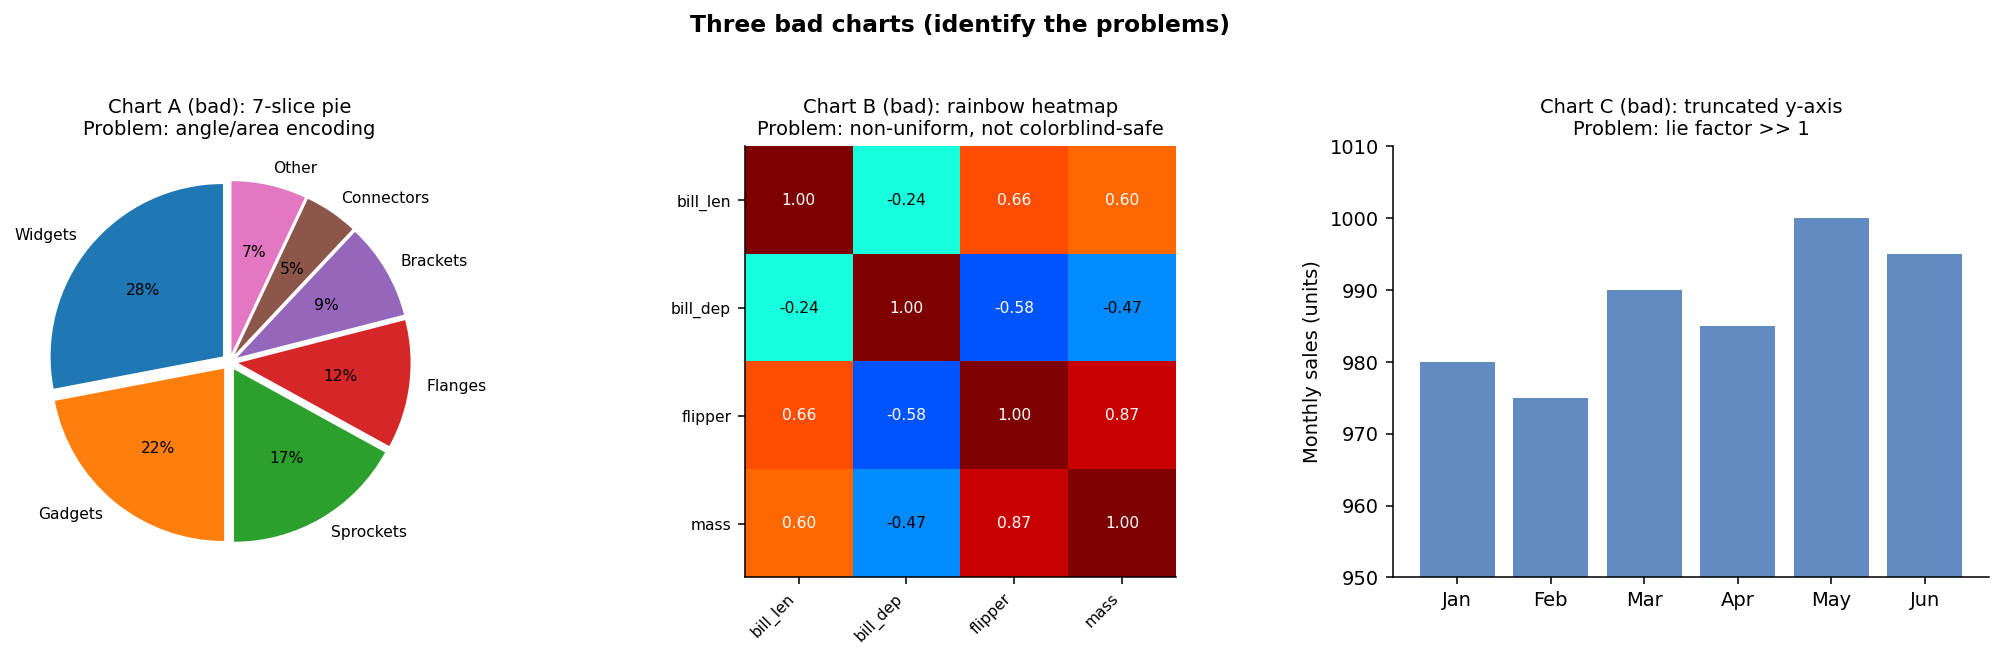

In [8]:
# =====================================================================
# Chart A (bad): pie chart with 7 slices
# =====================================================================
labels_a = ["Widgets", "Gadgets", "Sprockets", "Flanges",
            "Brackets", "Connectors", "Other"]
sizes_a = [28, 22, 17, 12, 9, 5, 7]
explode_a = [0.05] * 7

fig_bad, axes_bad = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes_bad[0]
ax.pie(sizes_a, labels=labels_a, autopct="%1.0f%%", startangle=90,
       explode=explode_a, textprops={"fontsize": 8})
ax.set_title("Chart A (bad): 7-slice pie\nProblem: angle/area encoding", fontsize=10)

# =====================================================================
# Chart B (bad): correlation heatmap with rainbow colormap
# =====================================================================
# Use penguins numeric correlations
corr_data = penguins[["bill_length_mm", "bill_depth_mm",
                       "flipper_length_mm", "body_mass_g"]].corr()
short_labels = ["bill_len", "bill_dep", "flipper", "mass"]

ax = axes_bad[1]
im = ax.imshow(corr_data.values, cmap="jet", vmin=-1, vmax=1)  # BAD colormap
ax.set_xticks(range(4))
ax.set_xticklabels(short_labels, fontsize=8, rotation=45, ha="right")
ax.set_yticks(range(4))
ax.set_yticklabels(short_labels, fontsize=8)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{corr_data.values[i, j]:.2f}", ha="center", va="center",
                fontsize=8, color="white" if abs(corr_data.values[i, j]) > 0.5 else "black")
ax.set_title("Chart B (bad): rainbow heatmap\nProblem: non-uniform, not colorblind-safe",
             fontsize=10)

# =====================================================================
# Chart C (bad): truncated y-axis bar chart
# =====================================================================
months_c = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
sales_c = [980, 975, 990, 985, 1000, 995]

ax = axes_bad[2]
ax.bar(months_c, sales_c, color="#1e5aa8", alpha=0.7)
ax.set_ylim(950, 1010)  # Truncated!
ax.set_ylabel("Monthly sales (units)")
ax.set_title("Chart C (bad): truncated y-axis\nProblem: lie factor >> 1", fontsize=10)

fig_bad.suptitle("Three bad charts (identify the problems)",
                 fontsize=12, y=1.03, fontweight="bold")
plt.tight_layout()
plt.show()

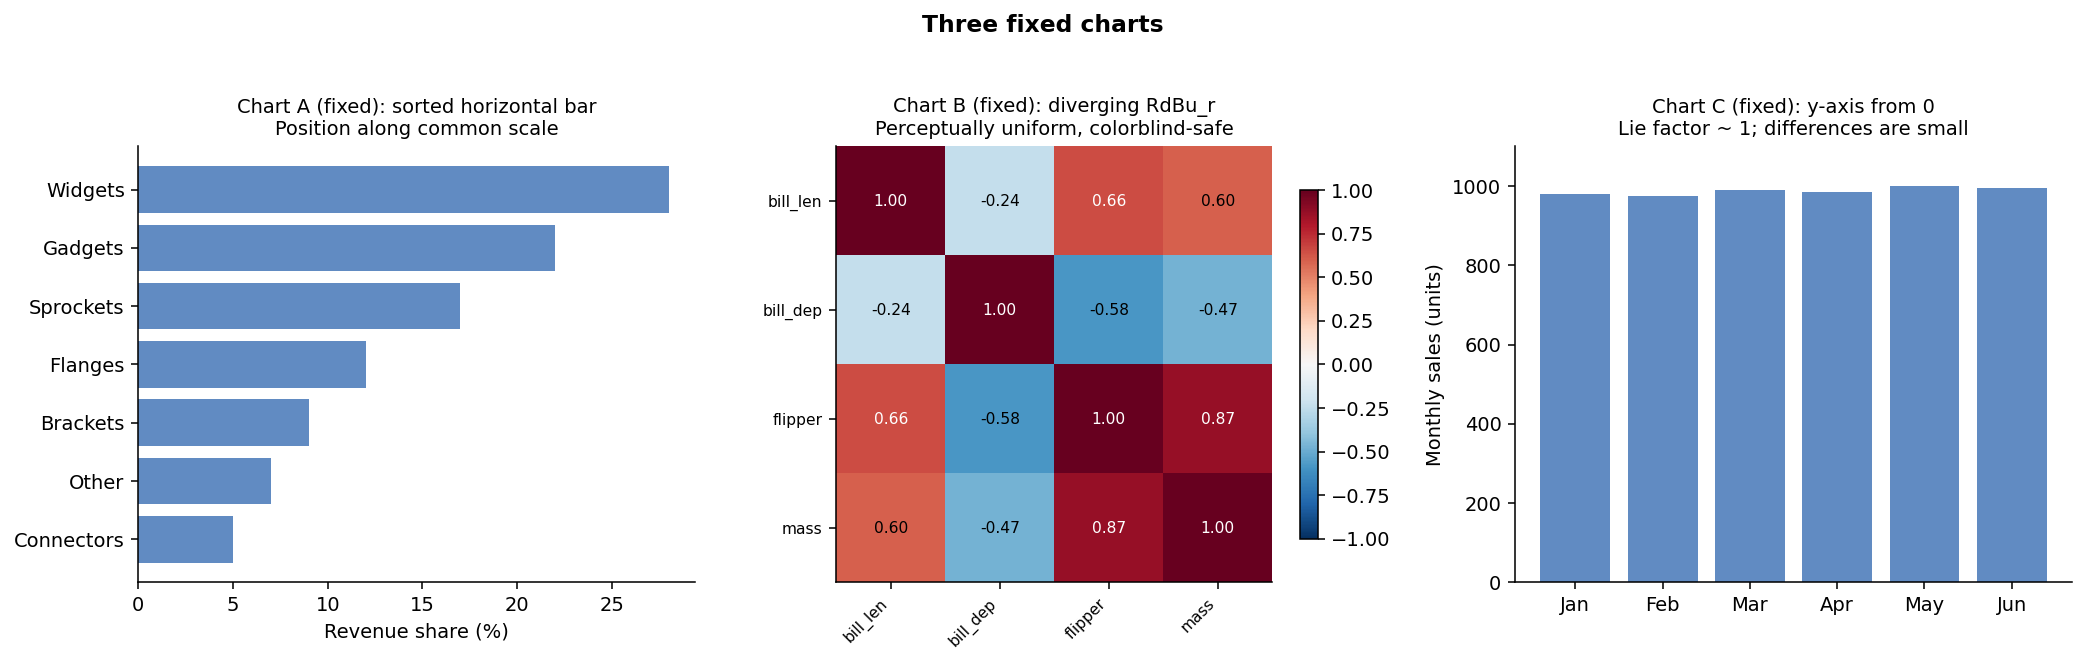

In [9]:
# =====================================================================
# Now the FIXED versions
# =====================================================================
fig_good, axes_good = plt.subplots(1, 3, figsize=(15, 4.5))

# ---- Fix A: sorted horizontal bar chart ----
ax = axes_good[0]
order = np.argsort(sizes_a)
ax.barh([labels_a[i] for i in order], [sizes_a[i] for i in order],
        color="#1e5aa8", alpha=0.7)
ax.set_xlabel("Revenue share (%)")
ax.set_title("Chart A (fixed): sorted horizontal bar\nPosition along common scale",
             fontsize=10)

# ---- Fix B: diverging colormap (RdBu_r) ----
ax = axes_good[1]
im = ax.imshow(corr_data.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(4))
ax.set_xticklabels(short_labels, fontsize=8, rotation=45, ha="right")
ax.set_yticks(range(4))
ax.set_yticklabels(short_labels, fontsize=8)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{corr_data.values[i, j]:.2f}", ha="center", va="center",
                fontsize=8, color="white" if abs(corr_data.values[i, j]) > 0.6 else "black")
fig_good.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Chart B (fixed): diverging RdBu_r\nPerceptually uniform, colorblind-safe",
             fontsize=10)

# ---- Fix C: y-axis starts at 0 ----
ax = axes_good[2]
ax.bar(months_c, sales_c, color="#1e5aa8", alpha=0.7)
ax.set_ylim(0, 1100)
ax.set_ylabel("Monthly sales (units)")
ax.set_title("Chart C (fixed): y-axis from 0\nLie factor ~ 1; differences are small",
             fontsize=10)

fig_good.suptitle("Three fixed charts",
                  fontsize=12, y=1.03, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Slide: Cleveland-McGill hierarchy -- quick illustration

The same data encoded as position (bar chart) vs. area (bubble chart) vs. angle (pie chart). One can see which encoding makes comparison easiest.

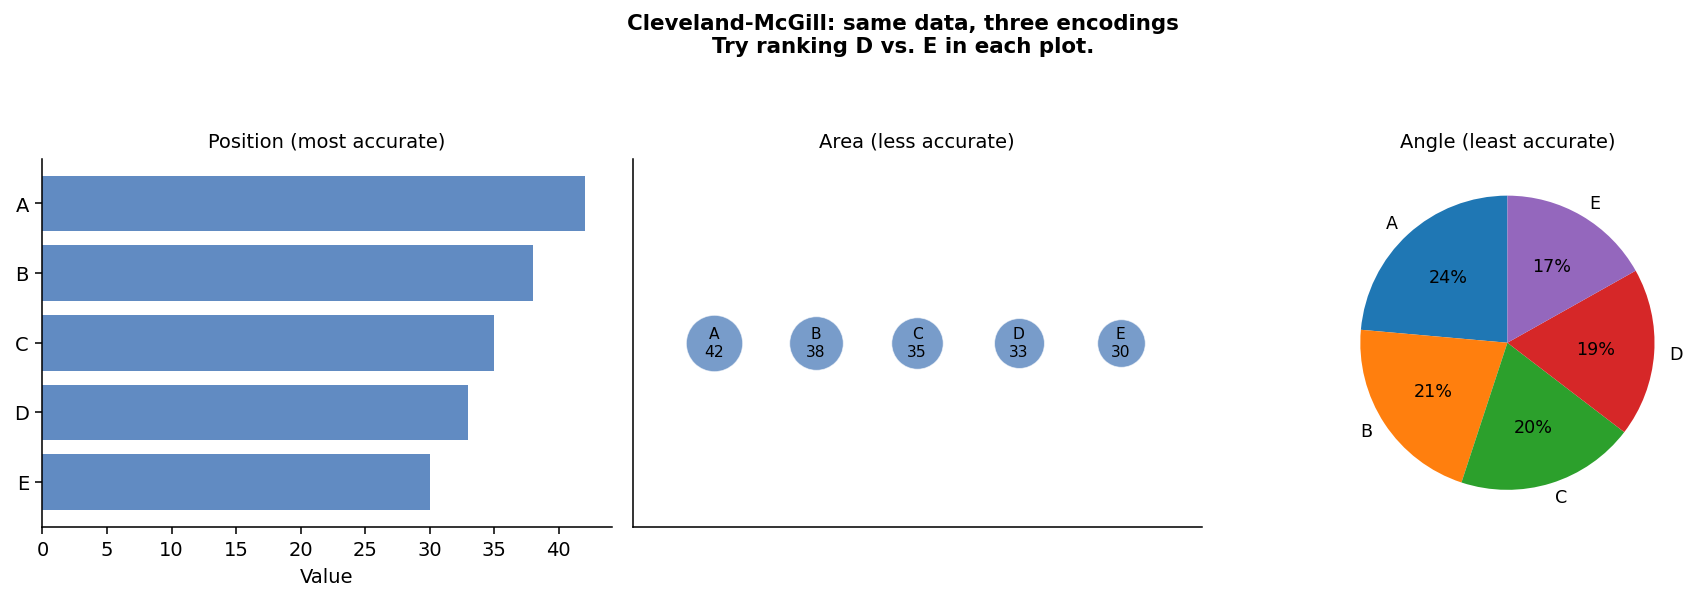

In [10]:
categories = ["A", "B", "C", "D", "E"]
values = [42, 38, 35, 33, 30]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Position: bar chart
ax = axes[0]
ax.barh(categories[::-1], values[::-1], color="#1e5aa8", alpha=0.7)
ax.set_xlabel("Value")
ax.set_title("Position (most accurate)", fontsize=10)

# Area: bubble chart
ax = axes[1]
for i, (cat, val) in enumerate(zip(categories, values)):
    ax.scatter(i, 0.5, s=val * 20, c="#1e5aa8", alpha=0.6,
               edgecolors="white", linewidths=0.5)
    ax.text(i, 0.5, f"{cat}\n{val}", ha="center", va="center", fontsize=8)
ax.set_xlim(-0.8, 4.8)
ax.set_ylim(-0.5, 1.5)
ax.set_yticks([])
ax.set_xticks([])
ax.set_title("Area (less accurate)", fontsize=10)

# Angle: pie chart
ax = axes[2]
ax.pie(values, labels=categories, autopct="%1.0f%%", startangle=90,
       textprops={"fontsize": 9})
ax.set_title("Angle (least accurate)", fontsize=10)

fig.suptitle("Cleveland-McGill: same data, three encodings\n"
             "Try ranking D vs. E in each plot.",
             fontsize=11, y=1.06, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Slide: Multiple-comparisons trap -- visual

Probability of at least one false positive as a function of the number of tests, at $\alpha = 0.05$.

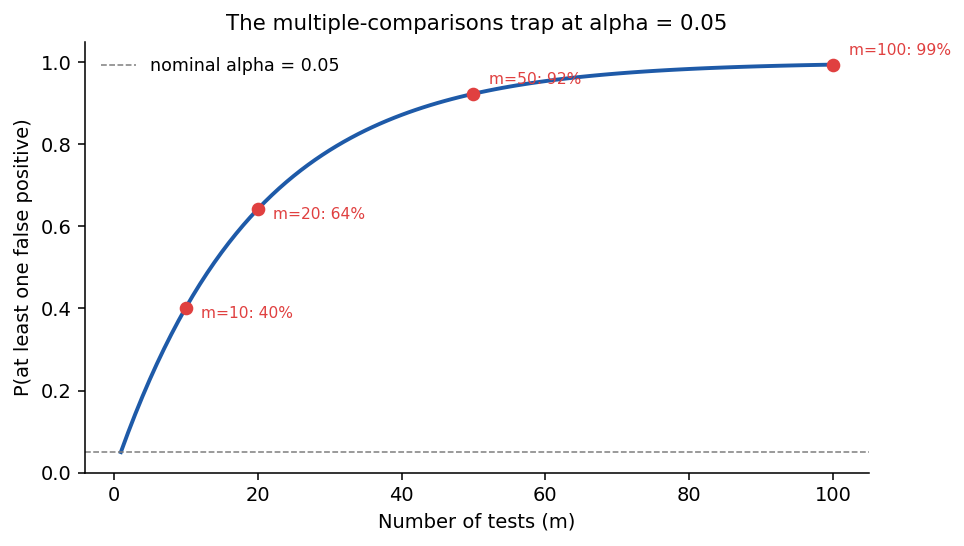

In [11]:
m = np.arange(1, 101)
p_false = 1 - (1 - 0.05) ** m

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(m, p_false, color="#1e5aa8", linewidth=2)
ax.axhline(0.05, color="gray", linestyle="--", linewidth=0.8, label="nominal alpha = 0.05")

# Mark key points
for m_val in [10, 20, 50, 100]:
    p_val = 1 - (1 - 0.05) ** m_val
    ax.plot(m_val, p_val, "o", color="#e04040", markersize=6, zorder=5)
    ax.annotate(f"m={m_val}: {p_val:.0%}", (m_val, p_val),
                textcoords="offset points", xytext=(8, -5 if m_val < 50 else 5),
                fontsize=8, color="#e04040")

ax.set_xlabel("Number of tests (m)")
ax.set_ylabel("P(at least one false positive)")
ax.set_title("The multiple-comparisons trap at alpha = 0.05")
ax.set_ylim(0, 1.05)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()